In [31]:
import torch
from d2l import torch as d2l

In [32]:
def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(dim=1, keepdim=True) #Sum along a row to calculate the demominator of the softmax function
    return X_exp / partition #Broadcasting mechanism is applied here

In [33]:
X = torch.rand((2,5))
X

tensor([[0.1417, 0.6066, 0.4365, 0.3111, 0.2345],
        [0.0460, 0.3964, 0.0435, 0.2856, 0.4542]])

In [34]:
X_prob = softmax(X)
X_prob, X_prob.sum(dim=1, keepdim=True)

(tensor([[0.1609, 0.2561, 0.2160, 0.1905, 0.1765],
         [0.1615, 0.2293, 0.1611, 0.2052, 0.2429]]),
 tensor([[1.0000],
         [1.0000]]))

In [43]:
class SoftmaxRegressionScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()

        #W is a dxq vector. Where d is the number of features and q is the number of output classes
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs), requires_grad=True)
        #b is a 1Xq row vector
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]

    def forward(self, X):
        X = X.reshape((-1, self.W.shape[0]))
        return softmax(torch.matmul(X, self.W) + self.b) #the bias vector will be broadcasted against the rows - its across all examples 

In [44]:
def cross_entropy(y_hat, y):
    """Function that calculates cross entropy - -ylog(y_hat)"""
    return -torch.log(y_hat[list(range(len(y_hat))), y]).mean()

In [45]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def loss(self, y_hat, y):
    return cross_entropy(y_hat, y)

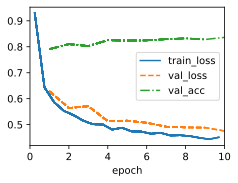

In [46]:
#Training the model
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

In [47]:
#prediction
X, y = next(iter(data.val_dataloader()))
preds = model(X).argmax(axis=1)
preds.shape

torch.Size([256])

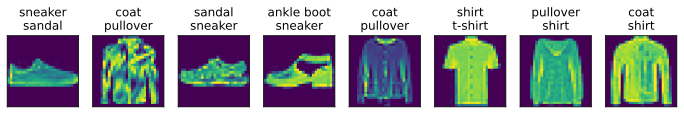

In [48]:
#Visualise the images that we have labeled incorrectly
wrong = preds.type(y.dtype) != y
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [a+'\n'+b for a, b in zip(data.text_labels(y), data.text_labels(preds))]
data.visualize([X, y], labels=labels)